In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as tts
from sklearn import preprocessing
from sklearn import neighbors
from sklearn import linear_model
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("titanic.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
data = data.drop(["PassengerId","Name"],axis=1)

In [4]:
data.shape

(891, 10)

In [5]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='str')

In [6]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
data.tail()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,0,2,male,27.0,0,0,211536,13.00,NaN,S
887,1,1,female,19.0,0,0,112053,30.00,B42,S
888,0,3,female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,1,1,male,26.0,0,0,111369,30.00,C148,C
890,0,3,male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
data.iloc[5]

Survived         0
Pclass           3
Sex           male
Age            NaN
SibSp            0
Parch            0
Ticket      330877
Fare        8.4583
Cabin          NaN
Embarked         Q
Name: 5, dtype: object

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    str    
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    str    
 9   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 69.7 KB


In [10]:
data["Ticket"].nunique()

681

In [11]:
data["Cabin"].nunique()

147

In [12]:
data = data.drop("Ticket",axis=1)

In [13]:
data["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [14]:
data["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [16]:
data.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [17]:
data["Embarked"].mode()[0]

'S'

In [18]:
data = data.drop("Cabin",axis=1)
data["Embarked"]=data["Embarked"].fillna(data["Embarked"].mode()[0])
data = data.dropna(subset=["Age"])

In [19]:
data.duplicated().sum()

np.int64(38)

In [20]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [21]:
for col in data.columns:
    if data[col].dtype in ["object", "str", "string"]:
        print(f"Column: {col}")
        print(data[col].value_counts())
        print("----------------------")

Column: Sex
Sex
male      421
female    255
Name: count, dtype: int64
----------------------
Column: Embarked
Embarked
S    520
C    128
Q     28
Name: count, dtype: int64
----------------------


In [22]:
encoder = preprocessing.LabelEncoder()

data["Sex"] = encoder.fit_transform(data["Sex"])
data["Embarked"] = encoder.fit_transform(data["Embarked"])

In [23]:
data["Sex"].value_counts()

Sex
1    421
0    255
Name: count, dtype: int64

In [24]:
data["Embarked"].value_counts()

Embarked
2    520
0    128
1     28
Name: count, dtype: int64

<Axes: >

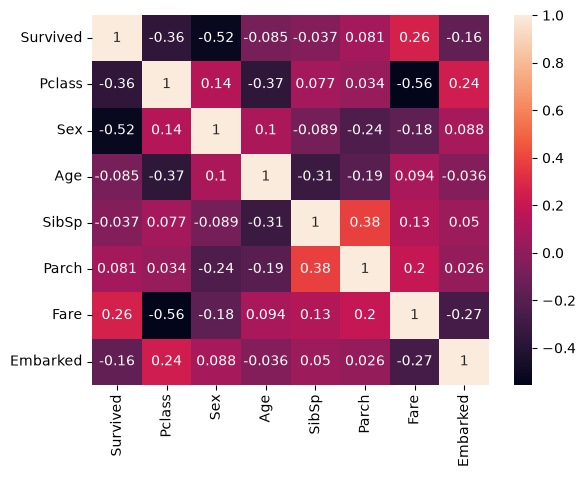

In [25]:
sns.heatmap(data.corr(),annot=True)


In [26]:
x = data.drop("Survived",axis=1)
y = data["Survived"]

In [27]:
x_train, x_test, y_train, y_test = tts(x,y,test_size=0.2,random_state=42)
x_train.shape, x_test.shape, y_train.shape,  y_test.shape

((540, 7), (136, 7), (540,), (136,))

In [28]:
x_cols = x_train.columns
x_cols

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='str')

In [29]:
x_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pclass,540.0,2.200000,0.846690,1.00,1.000,2.0,3.00,3.0000
Sex,540.0,0.624074,0.484810,0.00,0.000,1.0,1.00,1.0000
Age,540.0,29.901704,14.583249,0.42,20.375,28.0,39.00,71.0000
SibSp,540.0,0.512963,0.862440,0.00,0.000,0.0,1.00,5.0000
Parch,540.0,0.448148,0.878044,0.00,0.000,0.0,1.00,6.0000
Fare,540.0,36.449683,54.477783,0.00,8.050,16.1,36.75,512.3292
Embarked,540.0,1.570370,0.796940,0.00,2.000,2.0,2.00,2.0000


In [30]:
scaler = preprocessing.StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train),columns=x_cols)
x_test = scaler.transform(x_test)
x_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Pclass,540.0,-1.809252e-16,1.000927,-1.418599,-1.418599,-0.236433,0.945732,0.945732
Sex,540.0,-7.319248e-17,1.000927,-1.288448,-1.288448,0.776127,0.776127,0.776127
Age,540.0,8.223874e-17,1.000927,-2.023489,-0.653869,-0.130524,0.624465,2.820798
SibSp,540.0,3.782982e-17,1.000927,-0.595333,-0.595333,-0.595333,0.565244,5.207551
Parch,540.0,-6.579099e-18,1.000927,-0.510867,-0.510867,-0.510867,0.629084,6.328839
Fare,540.0,3.289550e-17,1.000927,-0.669695,-0.521791,-0.373887,0.005518,8.743395
Embarked,540.0,-3.618505e-17,1.000927,-1.972328,0.539599,0.539599,0.539599,0.539599


In [31]:
x_train.shape[0]

540

In [32]:
list_accuracy = []
for k in range(1,x_train.shape[0]):
    model_knn = neighbors.KNeighborsClassifier(k)
    model_knn.fit(x_train,y_train)
    y_pred1 = model_knn.predict(x_test)
    acc = metrics.accuracy_score(y_test,y_pred1)*100
    list_accuracy.append(acc)

best_k = list_accuracy.index(max(list_accuracy))
print(best_k)
print(list_accuracy[best_k])

13
83.08823529411765


In [33]:
model_knn = neighbors.KNeighborsClassifier(best_k+1)
model_knn.fit(x_train,y_train)
y_pred1 = model_knn.predict(x_test)
metrics.accuracy_score(y_test,y_pred1)*100

83.08823529411765

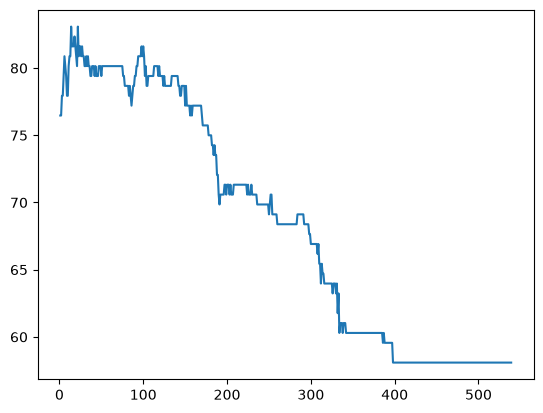

In [34]:
plt.plot(range(1,x_train.shape[0]) , list_accuracy)
plt.show()

In [35]:
# مدل های زیر را روی دیتای بالای آموزش بدید و دقتشان را محاسبه کنید
# logistic regression --- 79.41176470588235
# decision tree --- 72.79411764705883
# random forest --- 77.20588235294117
# knn --- 83.08823529411765

In [36]:
model_log = linear_model.LogisticRegression()
model_log.fit(x_train,y_train)
y_pred2 = model_log.predict(x_test)
metrics.accuracy_score(y_test,y_pred2)*100

79.41176470588235

In [37]:
model_tree = tree.DecisionTreeClassifier(random_state=42)
model_tree.fit(x_train,y_train)
y_pred3 = model_tree.predict(x_test)
metrics.accuracy_score(y_test,y_pred3)*100

72.79411764705883

In [38]:
model_forest = ensemble.RandomForestClassifier()
model_forest.fit(x_train,y_train)
y_pred4 = model_forest.predict(x_test)
metrics.accuracy_score(y_test,y_pred4)*100

76.47058823529412